In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the detailed results from your previous run
# results_df = pd.read_csv("../results/final_evaluation_detailed_results.csv")
results_df = pd.read_csv("../results/final_evaluation_detailed.csv")

print("Data loaded and prepped. Here's a preview:")
results_df.head()

Data loaded and prepped. Here's a preview:


,system_name,question,retrieval_f1,semantic_f1,predicted_answer,predicted_titles,gold_titles,hop_count,persona,error
0,LLM_Only_Baseline,Under what circumstances can awards be conferr...,0.0,0.177544,Awards are typically conferred during the offi...,[],['Awards Policy'],1,An administrative staff member managing univer...,NaN
1,LLM_Only_Baseline,I just spilled about 150 mL of concentrated su...,0.0,0.724138,Given the volume (150 mL) and the nature of th...,[],['Chemical Spill and Response Guideline'],1,A PhD candidate conducting complex laboratory ...,NaN
2,LLM_Only_Baseline,I've received a nomination form for someone to...,0.0,0.272727,The committee responsible for reviewing nomina...,[],['Honorary and Adjunct Title Holders Procedure'],1,An administrative staff member managing univer...,NaN
3,LLM_Only_Baseline,I'm a PhD student starting a research project ...,0.0,0.583333,As a PhD student working regularly with labora...,[],['Health Surveillance for Laboratory Animal Al...,1,A PhD candidate conducting complex laboratory ...,NaN
4,LLM_Only_Baseline,Who has the authority to approve naming reques...,0.0,0.190476,The authority to approve naming requests for s...,[],['Naming Policy'],1,An administrative staff member managing univer...,NaN


In [7]:
print(results_df.groupby("hop_count").size())

print(189/ 7)
print(35/ 7)
print(56/ 7)


hop_count
1    189
2     35
3     56
dtype: int64
27.0
5.0
8.0


In [50]:
results_df.iloc[246]

system_name                               AgenticRAG_Compiled_Agentic
question            What are the specific documentation and report...
retrieval_f1                                                      0.0
semantic_f1                                                  0.626016
predicted_answer    The documentation and reporting requirements f...
predicted_titles                 ['Incident Investigation Procedure']
gold_titles                      ['Incident Investigation Guideline']
hop_count                                                           1
persona             An administrative staff member managing univer...
error                                                             NaN
Name: 246, dtype: object

In [2]:
# Calculate and display the overall average scores
summary_df = results_df.groupby('system_name')[['retrieval_f1', 'semantic_f1']].mean().sort_values(by='semantic_f1', ascending=False)

print("--- Overall Average Scores ---")
print(summary_df)

import matplotlib.pyplot as plt
import seaborn as sns


# --- Overall Average Scores (old corpus) ---
#                                  retrieval_f1  answer_quality      semantic_f1
# system_name                                                  
# AgenticRAG_Compiled_TextSplit        0.624381           0.724         0.685223
# AgenticRAG_Compiled_Agentic          0.643206           0.664         0.637805
# AgenticRAG_Uncompiled_Agentic        0.542835           0.676         0.674225
# AgenticRAG_Uncompiled_TextSplit      0.571013           0.720         0.722206
# VanillaRAG_AgenticChunks             0.490857           0.560         0.520644
# VanillaRAG_TextSplitChunks           0.488476           0.516         0.482901
# LLM_Only_Baseline                    0.000000           0.544         ?

# --- Overall Average Scores (old synthetic) ---

#                                  retrieval_f1  semantic_f1
# system_name                                               
# AgenticRAG_Compiled_TextSplit        0.765686     0.717654
# AgenticRAG_Compiled_Agentic          0.761765     0.697669
# AgenticRAG_Uncompiled_Agentic        0.658870     0.688457
# AgenticRAG_Uncompiled_TextSplit      0.669328     0.652512
# VanillaRAG_Agentic                   0.533473     0.592953
# VanillaRAG_TextSplit                 0.559944     0.526086
# LLM_Only_Baseline                    0.000000     0.500329


--- Overall Average Scores ---
                                 retrieval_f1  semantic_f1
system_name                                               
AgenticRAG_Uncompiled_Agentic        0.652560     0.752924
AgenticRAG_Uncompiled_TextSplit      0.661250     0.736348
AgenticRAG_Compiled_Agentic          0.757222     0.734608
AgenticRAG_Compiled_TextSplit        0.725794     0.714254
VanillaRAG_Agentic                   0.511429     0.591140
LLM_Only_Baseline                    0.000000     0.530997
VanillaRAG_TextSplit                 0.509881     0.514730


In [16]:
# Filter to only rows where hop_count == 1
filtered_df = results_df[(results_df['hop_count'] == 1) & (results_df['system_name'] == "AgenticRAG_Compiled_Agentic")].copy()

# Compute the absolute delta between the two scores
filtered_df['delta_f1'] = (filtered_df['retrieval_f1'] - filtered_df['semantic_f1'])

# Sort descending by delta
sorted_df = filtered_df.sort_values(by='delta_f1', ascending=False)

# Display the index and both scores
for idx, row in sorted_df.iterrows():
    print(f"Index: {idx}, retrieval_f1: {row['retrieval_f1']}, semantic_f1: {row['semantic_f1']}, delta: {row['delta_f1']}")


Index: 235, retrieval_f1: 1.0, semantic_f1: 0.4, delta: 0.6
Index: 248, retrieval_f1: 1.0, semantic_f1: 0.5, delta: 0.5
Index: 263, retrieval_f1: 1.0, semantic_f1: 0.6, delta: 0.4
Index: 267, retrieval_f1: 1.0, semantic_f1: 0.6, delta: 0.4
Index: 250, retrieval_f1: 1.0, semantic_f1: 0.6666666666666666, delta: 0.33333333333333337
Index: 238, retrieval_f1: 1.0, semantic_f1: 0.7272727272727272, delta: 0.2727272727272728
Index: 236, retrieval_f1: 1.0, semantic_f1: 0.7272727272727273, delta: 0.2727272727272727
Index: 268, retrieval_f1: 1.0, semantic_f1: 0.7499999999999999, delta: 0.2500000000000001
Index: 241, retrieval_f1: 1.0, semantic_f1: 0.7692307692307693, delta: 0.23076923076923073
Index: 262, retrieval_f1: 1.0, semantic_f1: 0.7773851590106008, delta: 0.2226148409893992
Index: 234, retrieval_f1: 1.0, semantic_f1: 0.779291553133515, delta: 0.22070844686648505
Index: 243, retrieval_f1: 1.0, semantic_f1: 0.8, delta: 0.19999999999999996
Index: 240, retrieval_f1: 1.0, semantic_f1: 0.842105

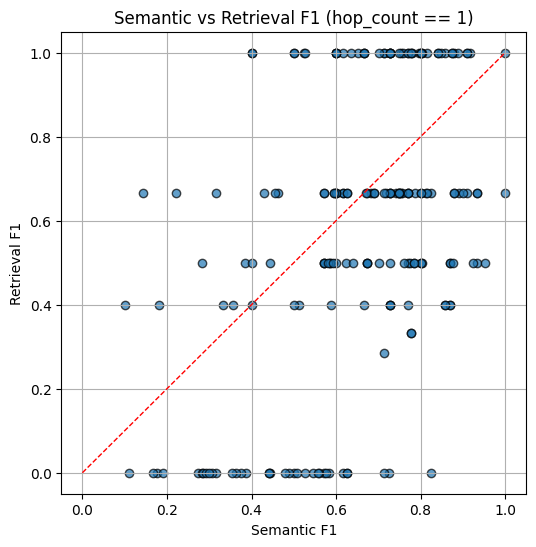

In [11]:
import matplotlib.pyplot as plt

# Filter to only hop_count == 1
filtered_df = results_df[results_df['hop_count'] == 1]

# Create the scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(
    filtered_df['semantic_f1'],
    filtered_df['retrieval_f1'],
    alpha=0.7,
    edgecolors='k'
)

# Label axes and title
plt.xlabel('Semantic F1')
plt.ylabel('Retrieval F1')
plt.title('Semantic vs Retrieval F1 (hop_count == 1)')

# Add a reference line (y = x) to show where they’re equal
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.grid(True)
plt.show()



--- Performance by Hop Count ---
                        system_name  hop_count  retrieval_f1  semantic_f1
0       AgenticRAG_Compiled_Agentic          1      0.777778     0.697181
1       AgenticRAG_Compiled_Agentic          2      0.822222     0.848483
2       AgenticRAG_Compiled_Agentic          3      0.647222     0.789751
3     AgenticRAG_Compiled_TextSplit          1      0.738977     0.690263
4     AgenticRAG_Compiled_TextSplit          2      0.822222     0.829673
5     AgenticRAG_Compiled_TextSplit          3      0.621032     0.723083
6     AgenticRAG_Uncompiled_Agentic          1      0.641975     0.758527
7     AgenticRAG_Uncompiled_Agentic          2      0.674286     0.787040
8     AgenticRAG_Uncompiled_Agentic          3      0.674702     0.712694
9   AgenticRAG_Uncompiled_TextSplit          1      0.661728     0.734753
10  AgenticRAG_Uncompiled_TextSplit          2      0.674286     0.797910
11  AgenticRAG_Uncompiled_TextSplit          3      0.651488     0.703256
12  

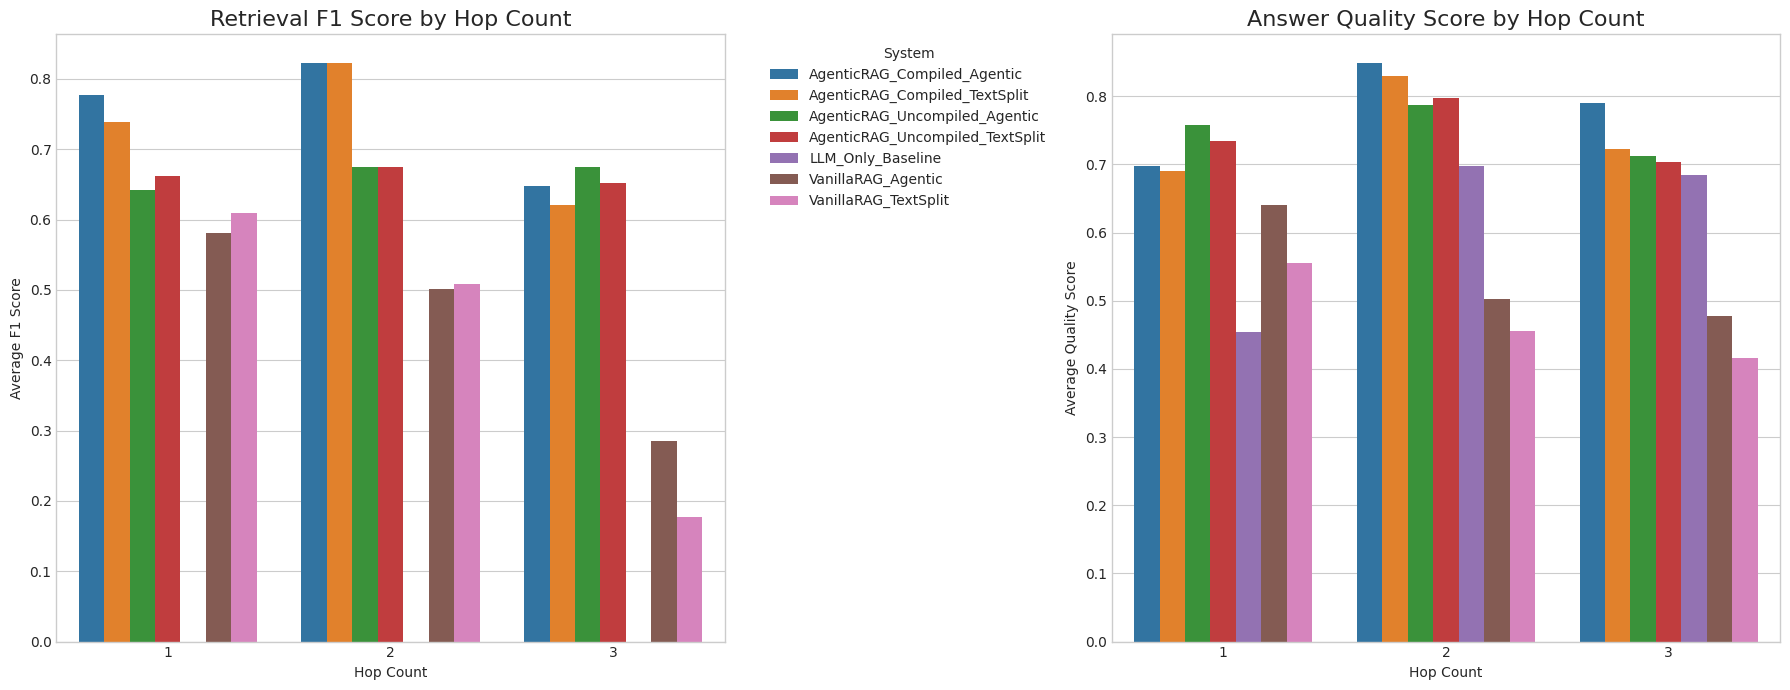

In [4]:
# Group by both system name and the new hop_count column
hop_level_summary = results_df.groupby(['system_name', 'hop_count'])[['retrieval_f1', 'semantic_f1']].mean().reset_index()

print("\n--- Performance by Hop Count ---")
print(hop_level_summary)

# --- Visualization ---
# A bar plot is a great way to visualize this.
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Plot for Retrieval F1
sns.barplot(data=hop_level_summary, x='hop_count', y='retrieval_f1', hue='system_name', ax=ax[0])
ax[0].set_title('Retrieval F1 Score by Hop Count', fontsize=16)
ax[0].set_xlabel('Hop Count')
ax[0].set_ylabel('Average F1 Score')
ax[0].legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot for Answer Quality
sns.barplot(data=hop_level_summary, x='hop_count', y='semantic_f1', hue='system_name', ax=ax[1])
ax[1].set_title('Answer Quality Score by Hop Count', fontsize=16)
ax[1].set_xlabel('Hop Count')
ax[1].set_ylabel('Average Quality Score')
ax[1].get_legend().remove() # Remove the duplicate legend

plt.tight_layout()
plt.show()

#                     system_name   retrieval_f1  semantic_f1
#     AgenticRAG_Compiled_Agentic   0.802469      0.717745
#   AgenticRAG_Compiled_TextSplit   0.790123      0.737494
#   AgenticRAG_Uncompiled_Agentic   0.667372      0.727501
# AgenticRAG_Uncompiled_TextSplit   0.687125      0.703006
#               LLM_Only_Baseline   0.000000      0.456041
#              VanillaRAG_Agentic   0.580247      0.640173
#            VanillaRAG_TextSplit   0.608642      0.533387

#      AgenticRAG_Compiled_Agentic     0.777778     0.697181
#    AgenticRAG_Compiled_TextSplit     0.738977     0.690263
#    AgenticRAG_Uncompiled_Agentic     0.641975     0.758527
#  AgenticRAG_Uncompiled_TextSplit     0.661728     0.734753
#               LLM_Only_Baseline      0.000000     0.454743
#              VanillaRAG_Agentic      0.580247     0.640997
#            VanillaRAG_TextSplit      0.608642     0.554777





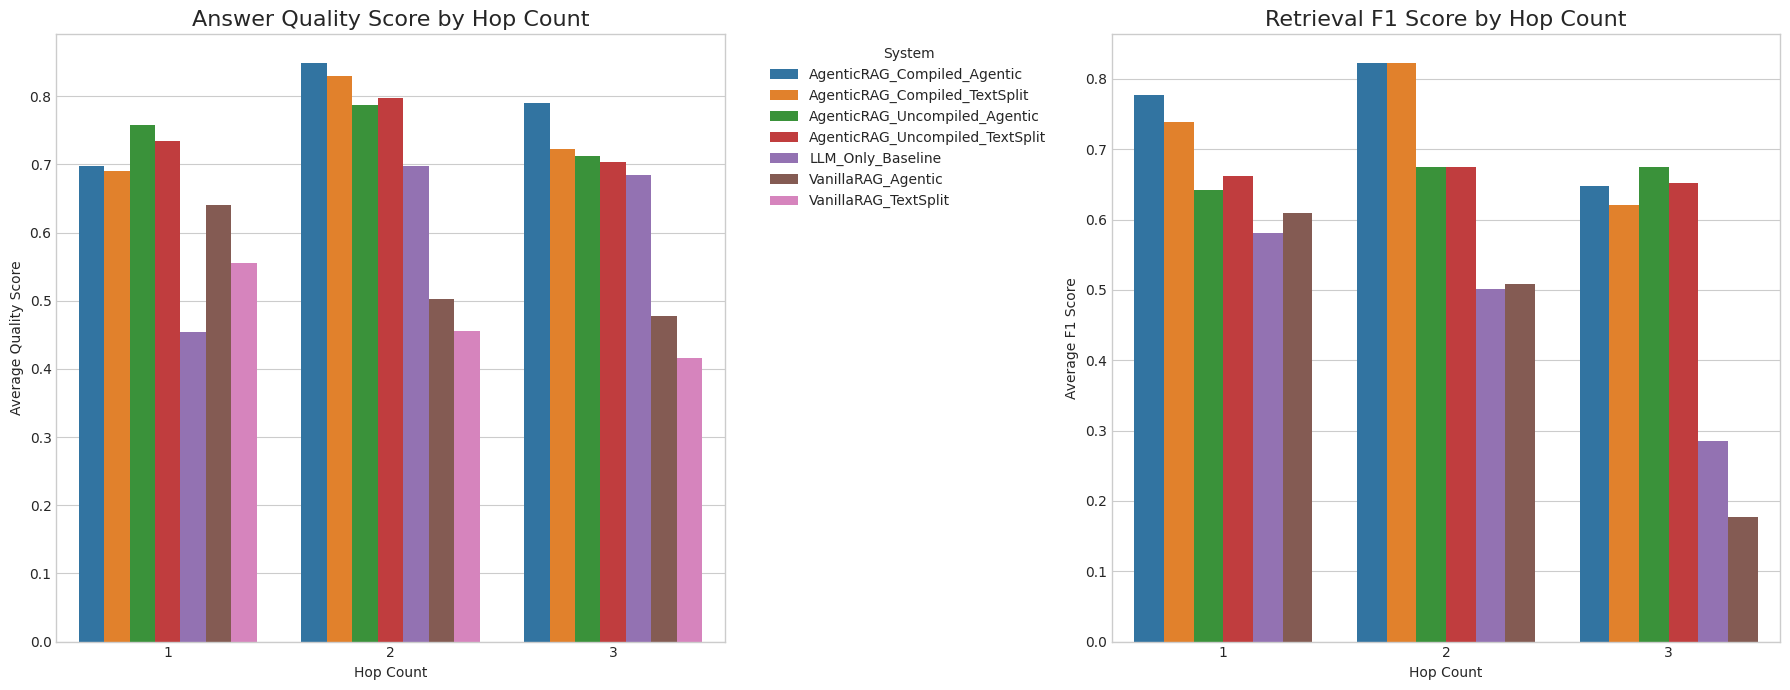

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by system_name and hop_count
hop_level_summary = results_df.groupby(['system_name', 'hop_count'])[['retrieval_f1', 'semantic_f1']].mean().reset_index()

# --- Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Retrieval F1 (exclude LLM_Only_Baseline) ---
retriever_data = hop_level_summary[hop_level_summary['system_name'] != 'LLM_Only_Baseline']
sns.barplot(data=retriever_data, x='hop_count', y='retrieval_f1', hue='system_name', ax=ax[1])
ax[1].set_title('Retrieval F1 Score by Hop Count', fontsize=16)
ax[1].set_xlabel('Hop Count')
ax[1].set_ylabel('Average F1 Score')
ax[1].get_legend().remove()  # Remove legend from left plot

# --- Plot 2: Semantic F1 (include all systems) ---
sns.barplot(data=hop_level_summary, x='hop_count', y='semantic_f1', hue='system_name', ax=ax[0])
ax[0].set_title('Answer Quality Score by Hop Count', fontsize=16)
ax[0].set_xlabel('Hop Count')
ax[0].set_ylabel('Average Quality Score')
# Legend stays on the right plot
ax[0].legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


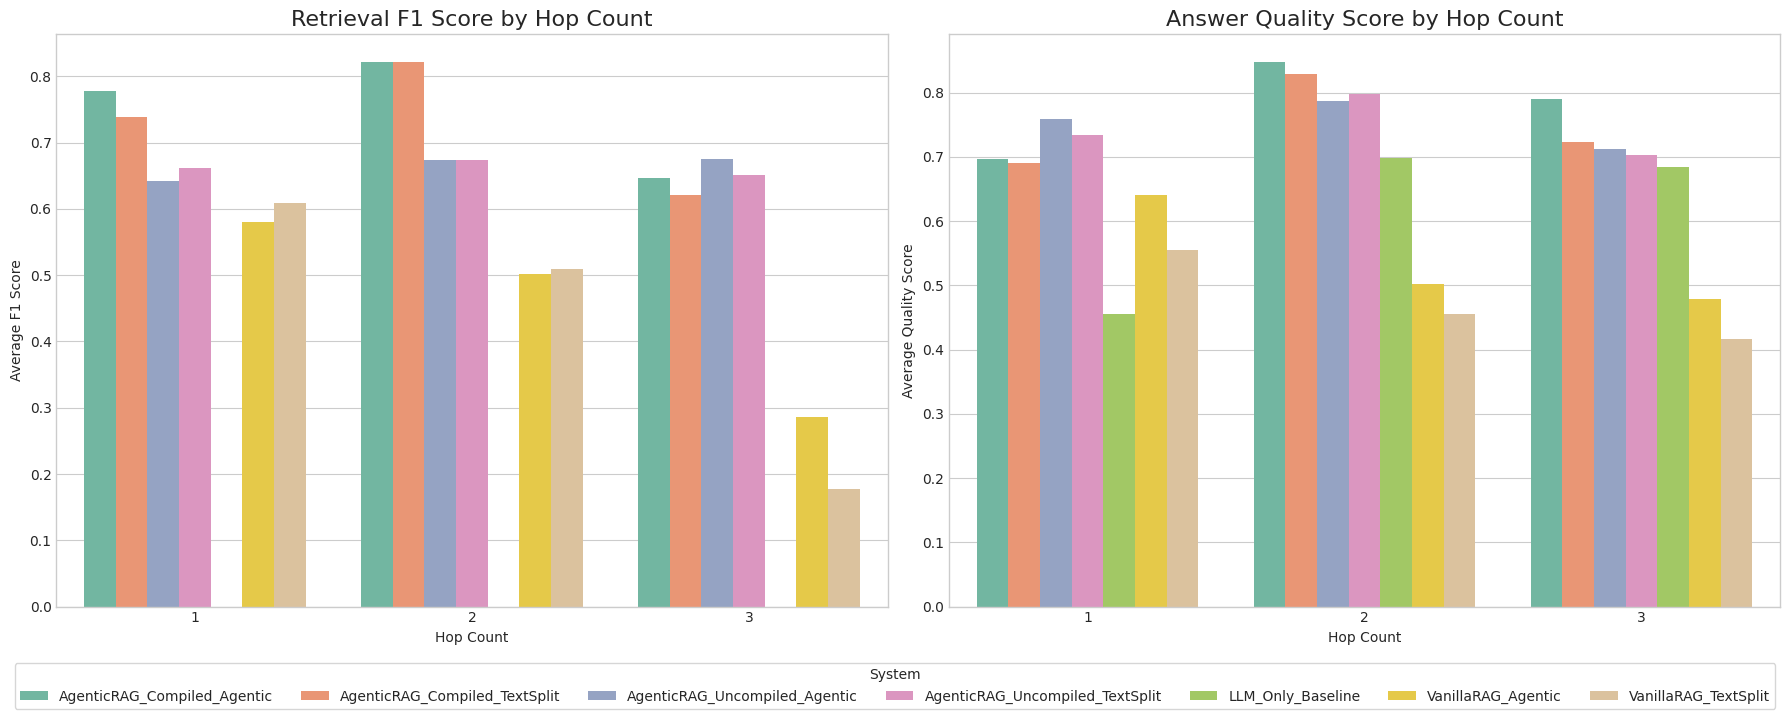

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by both system name and hop_count
hop_level_summary = results_df.groupby(['system_name', 'hop_count'])[['retrieval_f1', 'semantic_f1']].mean().reset_index()


# --- Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Retrieval F1 (exclude LLM_Only_Baseline) ---
retriever_data = hop_level_summary[hop_level_summary['system_name'] != 'LLM_Only_Baseline']

sns.barplot(data=hop_level_summary, x='hop_count', y='retrieval_f1', hue='system_name', ax=ax[0],palette='Set2')
ax[0].set_title('Retrieval F1 Score by Hop Count', fontsize=16)
ax[0].set_xlabel('Hop Count')
ax[0].set_ylabel('Average F1 Score')

# Plot for Answer Quality
sns.barplot(data=hop_level_summary, x='hop_count', y='semantic_f1', hue='system_name', ax=ax[1],palette='Set2')
ax[1].set_title('Answer Quality Score by Hop Count', fontsize=16)
ax[1].set_xlabel('Hop Count')
ax[1].set_ylabel('Average Quality Score')

# --- Unified legend in the middle ---
handles, labels = ax[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='System',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),  # adjust vertical position if needed
    ncol=len(labels),  # spread across horizontally
    frameon=True
)

# Remove individual legends
ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave room for legend
plt.savefig("figures/hop_level_summary.png", dpi=300)
plt.show()



--- Performance by Hop Count ---
                        system_name  hop_count  retrieval_f1  semantic_f1
0       AgenticRAG_Compiled_Agentic          1      0.777778     0.697181
1       AgenticRAG_Compiled_Agentic          2      0.822222     0.848483
2       AgenticRAG_Compiled_Agentic          3      0.647222     0.789751
3     AgenticRAG_Compiled_TextSplit          1      0.738977     0.690263
4     AgenticRAG_Compiled_TextSplit          2      0.822222     0.829673
5     AgenticRAG_Compiled_TextSplit          3      0.621032     0.723083
6     AgenticRAG_Uncompiled_Agentic          1      0.641975     0.758527
7     AgenticRAG_Uncompiled_Agentic          2      0.674286     0.787040
8     AgenticRAG_Uncompiled_Agentic          3      0.674702     0.712694
9   AgenticRAG_Uncompiled_TextSplit          1      0.661728     0.734753
10  AgenticRAG_Uncompiled_TextSplit          2      0.674286     0.797910
11  AgenticRAG_Uncompiled_TextSplit          3      0.651488     0.703256
12  

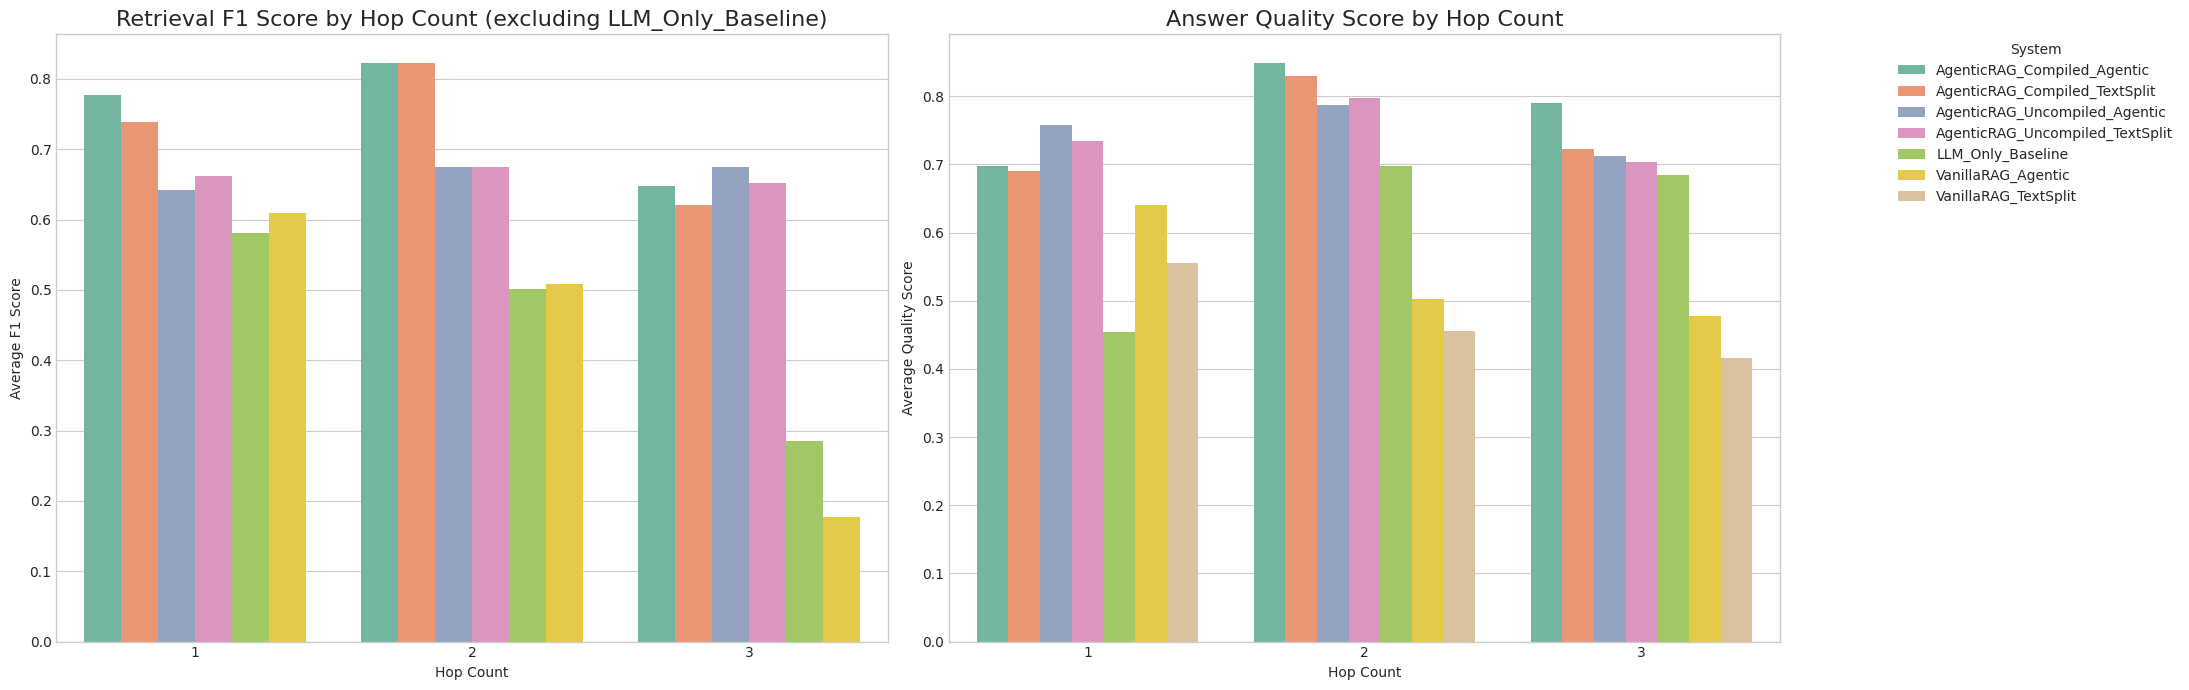

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by both system name and hop_count
hop_level_summary = results_df.groupby(['system_name', 'hop_count'])[['retrieval_f1', 'semantic_f1']].mean().reset_index()

print("\n--- Performance by Hop Count ---")
print(hop_level_summary)

# --- Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Retrieval F1 (exclude LLM_Only_Baseline) ---
retriever_data = hop_level_summary[hop_level_summary['system_name'] != 'LLM_Only_Baseline']

sns.barplot(data=retriever_data, x='hop_count', y='retrieval_f1', hue='system_name', palette='Set2', ax=ax[0])
ax[0].set_title('Retrieval F1 Score by Hop Count (excluding LLM_Only_Baseline)', fontsize=16)
ax[0].set_xlabel('Hop Count')
ax[0].set_ylabel('Average F1 Score')

# --- Plot 2: Semantic F1 (include all systems) ---
sns.barplot(data=hop_level_summary, x='hop_count', y='semantic_f1', hue='system_name', palette='Set2', ax=ax[1])
ax[1].set_title('Answer Quality Score by Hop Count', fontsize=16)
ax[1].set_xlabel('Hop Count')
ax[1].set_ylabel('Average Quality Score')

# --- Unified legend for both plots ---
handles, labels = ax[1].get_legend_handles_labels()  # take from unfiltered plot
fig.legend(handles, labels, title='System', bbox_to_anchor=(1.05, 0.95), loc='upper left')

# Remove individual legends
ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.tight_layout()
plt.show()


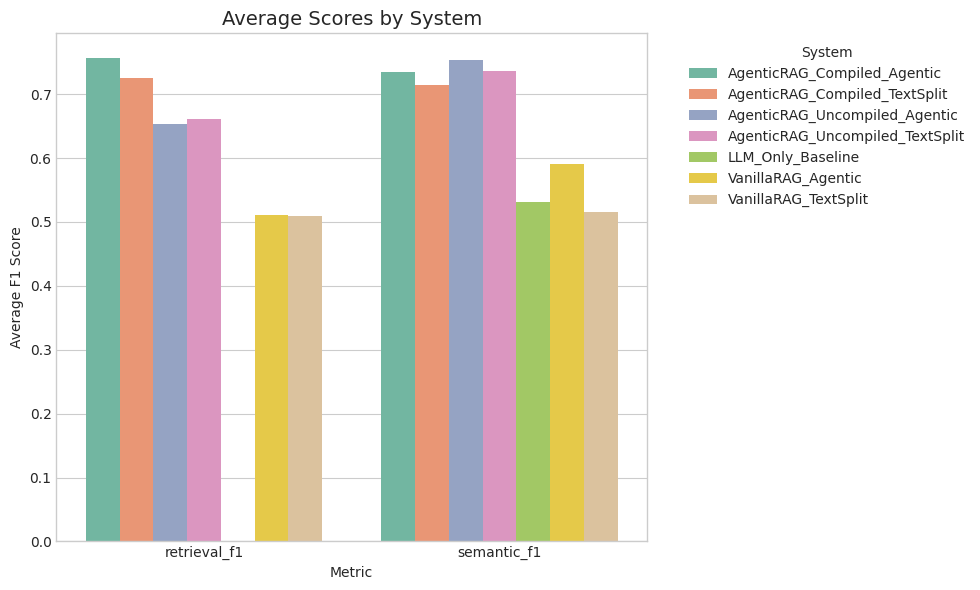

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Compute average scores by system_name ---
system_summary = results_df.groupby('system_name')[['retrieval_f1', 'semantic_f1']].mean().reset_index()

# --- Step 2: Convert to long format ---
long_summary = system_summary.melt(
    id_vars='system_name',
    value_vars=['retrieval_f1', 'semantic_f1'],
    var_name='metric',
    value_name='score'
)

# --- Step 3: Create bar plot with legend ---
plt.figure(figsize=(10, 6))
sns.barplot(data=long_summary, x='metric', y='score', hue='system_name', palette='Set2')

plt.title('Average Scores by System', fontsize=14)
plt.xlabel('Metric')
plt.ylabel('Average F1 Score')

plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')  # legend on the right
plt.tight_layout()
plt.show()
plt.savefig("figures/average_scores.png")


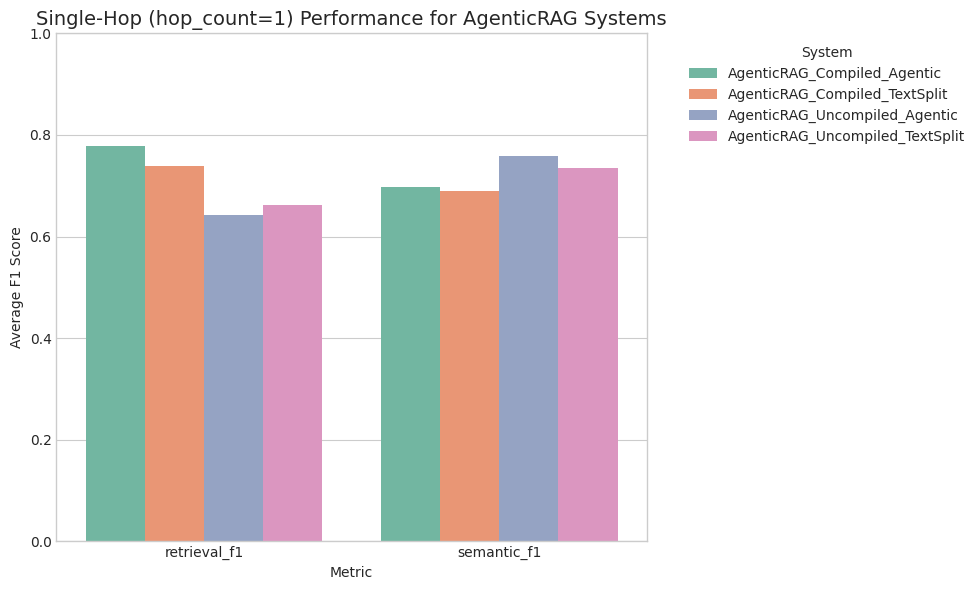

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Filter for single-hop AgenticRAG systems ---
agentic_systems = [
    'AgenticRAG_Compiled_Agentic',
    'AgenticRAG_Compiled_TextSplit',
    'AgenticRAG_Uncompiled_Agentic',
    'AgenticRAG_Uncompiled_TextSplit'
]

filtered_df = results_df[
    (results_df['system_name'].isin(agentic_systems)) &
    (results_df['hop_count'] == 1)
]

# --- Step 2: Compute average scores by system ---
summary = filtered_df.groupby('system_name')[['retrieval_f1', 'semantic_f1']].mean().reset_index()

# --- Step 3: Convert to long format for seaborn ---
long_summary = summary.melt(
    id_vars='system_name',
    value_vars=['retrieval_f1', 'semantic_f1'],
    var_name='metric',
    value_name='score'
)

# --- Step 4: Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(data=long_summary, x='metric', y='score', hue='system_name', palette='Set2')

plt.title('Single-Hop (hop_count=1) Performance for AgenticRAG Systems', fontsize=14)
plt.xlabel('Metric')
plt.ylabel('Average F1 Score')

plt.ylim(0, 1)  # Assuming F1 scores are normalized
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
